In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# 1. Load the dataset
df = pd.read_csv('Zomato-data-.csv')

In [8]:
# 2. Data Cleaning
# Extract numeric value from 'rate' column (e.g., '4.1/5' -> 4.1)
def clean_rate(val):
    if isinstance(val, str):
        if '/' in val:
            return float(val.split('/')[0])
        else:
            try:
                return float(val)
            except ValueError:
                return None
    return val

df['rate_numeric'] = df['rate'].apply(clean_rate)

In [9]:
# 3. Set visualization style
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# --- VISUALIZATIONS ---

C:\Users\DELL\AppData\Local\Temp\ipykernel_5632\352728586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='online_order', data=df, ax=axes[0], palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_5632\352728586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='book_table', data=df, ax=axes[1], palette='magma')


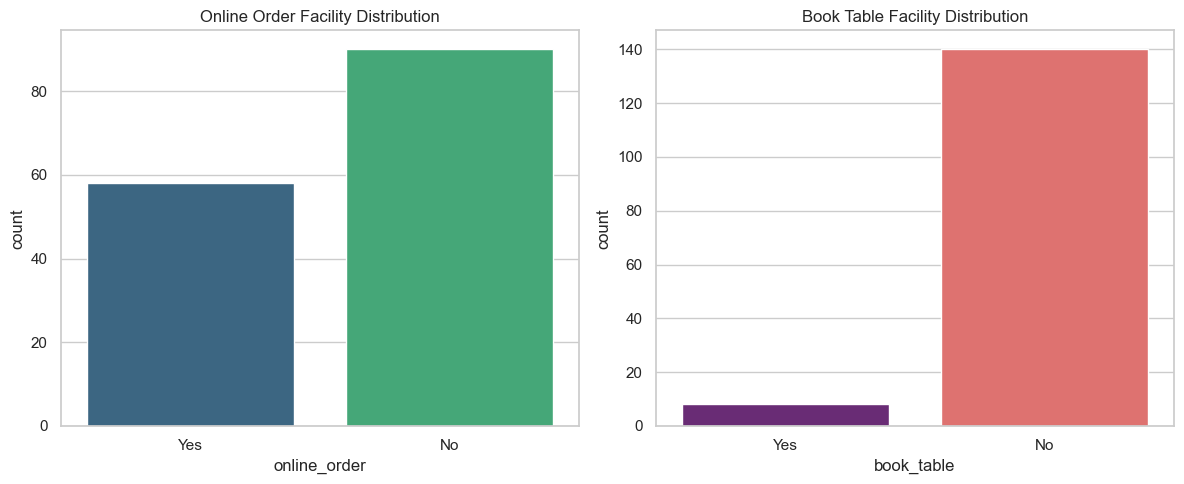

In [10]:
# A. Online Order and Book Table Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='online_order', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Online Order Facility Distribution')
sns.countplot(x='book_table', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Book Table Facility Distribution')
plt.tight_layout()
plt.savefig('order_table_distribution.png')

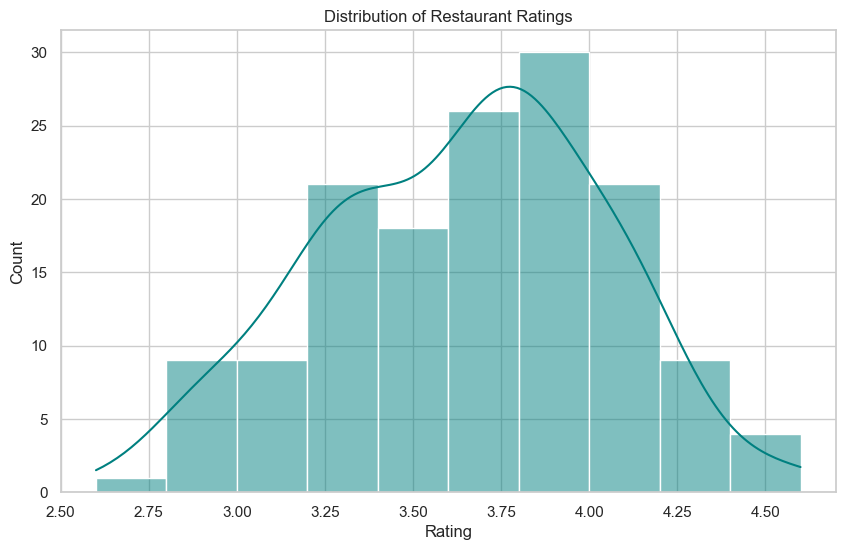

In [11]:
# B. Distribution of Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['rate_numeric'].dropna(), bins=10, kde=True, color='teal')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.savefig('rating_distribution.png')

C:\Users\DELL\AppData\Local\Temp\ipykernel_5632\193003281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rate_numeric', y='listed_in(type)', data=avg_rating, palette='cool')


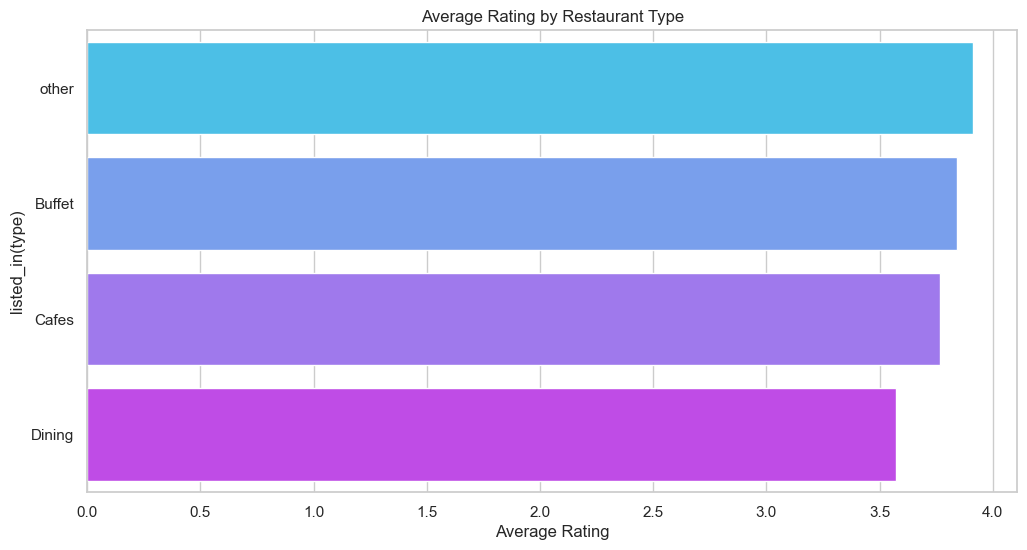

In [13]:
# C. Average Rating per Restaurant Type
plt.figure(figsize=(12, 6))
avg_rating = df.groupby('listed_in(type)')['rate_numeric'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='rate_numeric', y='listed_in(type)', data=avg_rating, palette='cool')
plt.title('Average Rating by Restaurant Type')
plt.xlabel('Average Rating')
plt.savefig('avg_rating_per_type.png')

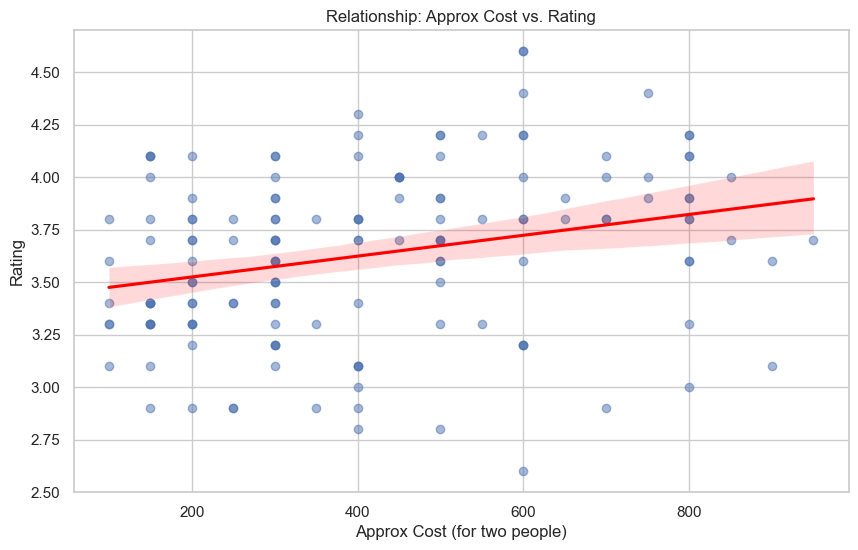

In [14]:
# D. Relationship: Approx Cost vs. Rating
plt.figure(figsize=(10, 6))
sns.regplot(x='approx_cost(for two people)', y='rate_numeric', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={"color": "red"})
plt.title('Relationship: Approx Cost vs. Rating')
plt.xlabel('Approx Cost (for two people)')
plt.ylabel('Rating')
plt.savefig('cost_vs_rating.png')

In [15]:
# Calculate summary metrics
insights = {
    'Total Restaurants': len(df),
    'Average Rating': df['rate_numeric'].mean(),
    'Average Cost': df['approx_cost(for two people)'].mean(),
    'Top Voted': df.nlargest(5, 'votes')[['name', 'votes']],
    'Highest Rated': df[df['votes'] > 100].nlargest(5, 'rate_numeric')[['name', 'rate_numeric']]
}

print(f"Total Restaurants: {insights['Total Restaurants']}")
print(f"Average Rating: {insights['Average Rating']:.2f}")
print(f"Average Cost for Two: {insights['Average Cost']:.2f}")
print("\nTop 5 Voted Restaurants:\n", insights['Top Voted'])

Total Restaurants: 148
Average Rating: 3.63
Average Cost for Two: 418.24

Top 5 Voted Restaurants:
                  name  votes
38  Empire Restaurant   4884
86      Meghana Foods   4401
7              Onesta   2556
44             Onesta   2556
65        Kabab Magic   1720


In [21]:
print("TrendsCost vs. Quality: There is a slight positive correlation ($r > 0$) between cost and rating, suggesting that higher-priced restaurants generally offer a better experience.Top Categories: Buffet and Cafes tend to have higher average ratings compared to standard dining outlets.")

TrendsCost vs. Quality: There is a slight positive correlation ($r > 0$) between cost and rating, suggesting that higher-priced restaurants generally offer a better experience.Top Categories: Buffet and Cafes tend to have higher average ratings compared to standard dining outlets.
